In [1]:
# Importing necessary libraries
import numpy as np
import gempy as gp
import pyvista as pv
from gempy_engine.core.data.stack_relation_type import StackRelationType
import matplotlib.pyplot as plt
import gstools as gs

Setting Backend To: AvailableBackends.numpy


In [2]:
# Gempy model (everything) - medium resolution now, you can ramp up the refinement to 7 normally, but takes more time
# Generate the model
# Define the path to data
data_path = 'https://raw.githubusercontent.com/cgre-aachen/gempy_data/master/'
path_to_data = data_path + "/data/input_data/jan_models/"
# Create a GeoModel instance
geo_model = gp.create_geomodel(
    project_name='combination',
    extent=[0, 2500, 0, 1000, 0, 1000],
    refinement=5,
    resolution=[125, 50, 50],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=path_to_data + "model7_orientations.csv",
        path_to_surface_points=path_to_data + "model7_surface_points.csv"
    )
)
# Map geological series to surfaces
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "Fault_Series": ('fault'),
        "Strat_Series1": ('rock3'),
        "Strat_Series2": ('rock2', 'rock1'),
    }
)
# Define the structural relation
geo_model.structural_frame.structural_groups[0].structural_relation = StackRelationType.FAULT
geo_model.structural_frame.fault_relations = np.array(
    [[0, 1, 1],
     [0, 0, 0],
     [0, 0, 0]]
)

# This is how you would change colors in gempy by element id, don't think it is necessary for you
# geo_model.structural_frame.structural_elements[0].color = "#000000"  # make fault black for example
# geo_model.structural_frame.basement_color = "#000000"  # basement is a little different

# Compute the geological model
# geo_model.interpolation_options.number_octree_levels_surface = 5
gp.compute_model(geo_model)

Surface points hash:  dd7b2f714c1c20cb7ce615c5c47ecc4cf3ca2ee3419e4090b2f11fbf633d459f
Orientations hash:  4043b59bbfa7012abd818f04f74e2b0667ba970dd71c781512289bc073f5a6d5
Setting Backend To: AvailableBackends.numpy
Chunking done: 6 chunks
Chunking done: 14 chunks
Chunking done: 66 chunks
Chunking done: 6 chunks
Chunking done: 6 chunks


Solutions(5 Octree Levels, 4 DualContouringMeshes)

In [3]:
# Just for completeness - get the extent from gempy model
model_extent = geo_model.grid.extent

In [4]:
# Creat a structured pyvista grid from a gempy model

# Define grid dimensions (number of voxels along each axis)
nx, ny, nz = 125, 50, 50  # Number of voxels in each direction (res)

# Define the range for x, y, z and calculate voxel centers
dx = 2500 / nx
dy = 1000 / ny
dz = 1000 / nz

# Similar to gempy grid bur plus one for meshing
gridx = np.linspace(0, 2500, nx+1)
gridy = np.linspace(0, 1000, ny+1)
gridz = np.linspace(0, 1000, nz+1)

# Create a 3D meshgrid for the coordinates, voxel centers
X, Y, Z = np.meshgrid(gridx, gridy, gridz, indexing="ij")

# Reshape the coordinates to fit into the StructuredGrid format
points = np.c_[X.T.ravel(), Y.T.ravel(), Z.T.ravel()]

# Create a PyVista StructuredGrid object
grid = pv.StructuredGrid()
grid.points = points
grid.dimensions = [nx+1, ny+1, nz+1] # One bigger as gempy grid


# Assign the voxel colors to the grid's cell data
grid.cell_data['lithology'] = geo_model.solutions.raw_arrays.lith_block.reshape([nx, ny, nz]).T.flatten(order="C")


C:\Users\vonha\PycharmProjects\codebase\venv\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


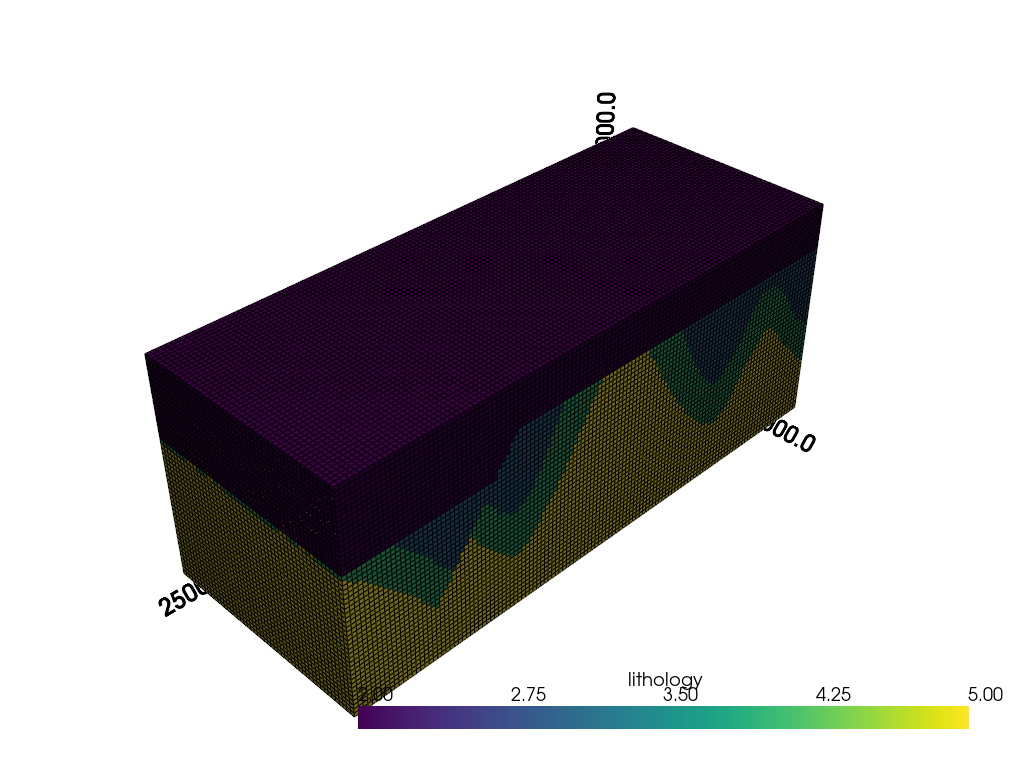

In [5]:
# 3D plot lithologies
plotter = pv.Plotter()

plotter.add_mesh(grid, scalars='lithology', show_edges=True)

# Set the bounds and grid of the plotter
plotter.show_bounds(bounds=model_extent,
                    location="furthest",
                    grid=True)

# Display the interactive plot
plotter.show()


C:\Users\vonha\PycharmProjects\codebase\venv\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


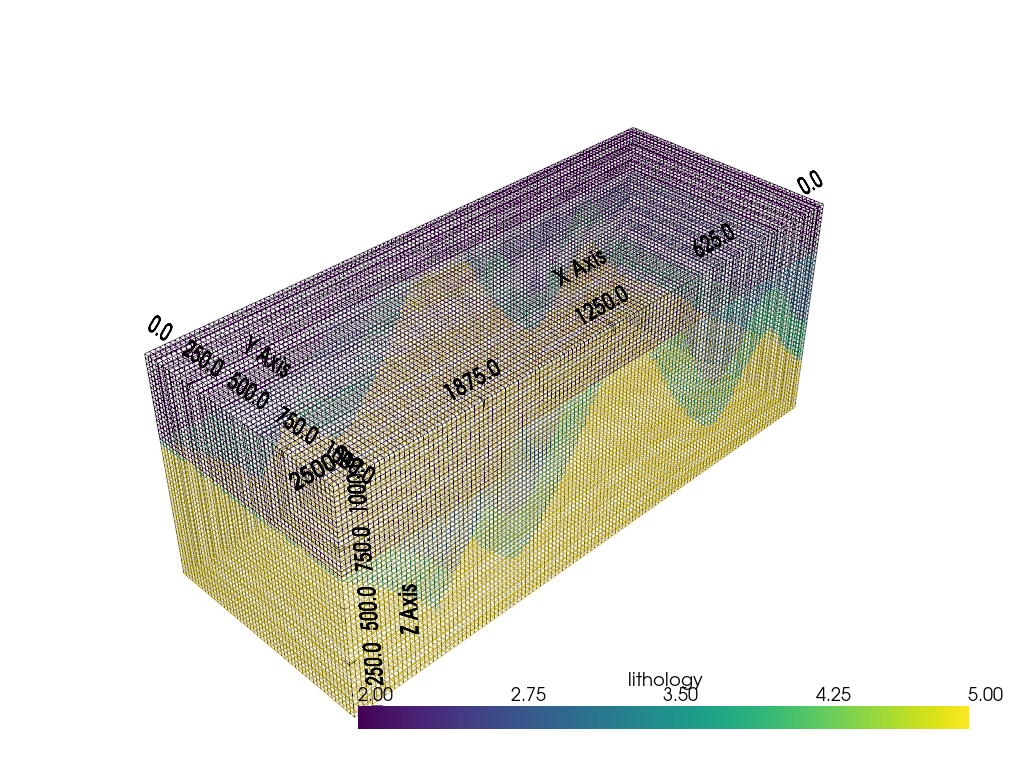

In [6]:
# Wireframe 3D plot with gempy model colors
plotter = pv.Plotter()

plotter.add_mesh(grid, show_edges=True, style='wireframe')

plotter.show_bounds()
plotter.show()

In [7]:
# Separate into multiblock 
grid.set_active_scalars("lithology")
multi_mesh = pv.MultiBlock()

for i in np.unique(geo_model.solutions.raw_arrays.lith_block):
    threshed = grid.threshold((i-0.5,i+0.5))
    multi_mesh.append(threshed)

In [8]:
# Random field generation with random variogram models
fields = []
for i in range(4):
    centers = multi_mesh[i].cell_centers()
    x = centers.points[:,0]
    y = centers.points[:,1]
    z = centers.points[:,2]
    model = gs.Gaussian(dim=3, var=np.random.randint(1,20), len_scale=np.random.random()*1000)
    srf = gs.SRF(model, seed=20170519)
    fields.append(np.round(srf((x, y, z)), 0))
    multi_mesh[i].cell_data["values"]=fields[i]+np.random.randint(1,20)

C:\Users\vonha\PycharmProjects\codebase\venv\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


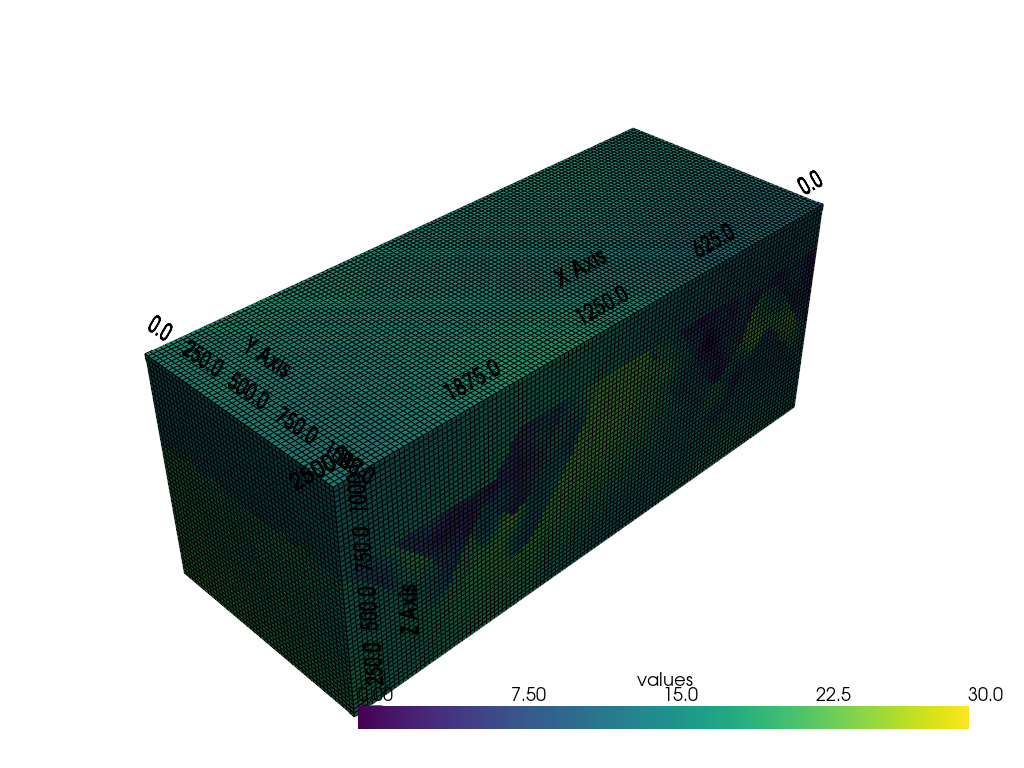

In [9]:
plotter = pv.Plotter()

for i in range(4):
    plotter.add_mesh(multi_mesh[i], show_edges=True, scalars="values")

# plotter.add_mesh(centers, color="r", point_size=8.0, render_points_as_spheres=True)
# plotter.add_mesh(pvnc[0][2], show_edges=True, style='wireframe')

plotter.show_bounds()
plotter.show()

C:\Users\vonha\PycharmProjects\codebase\venv\Lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


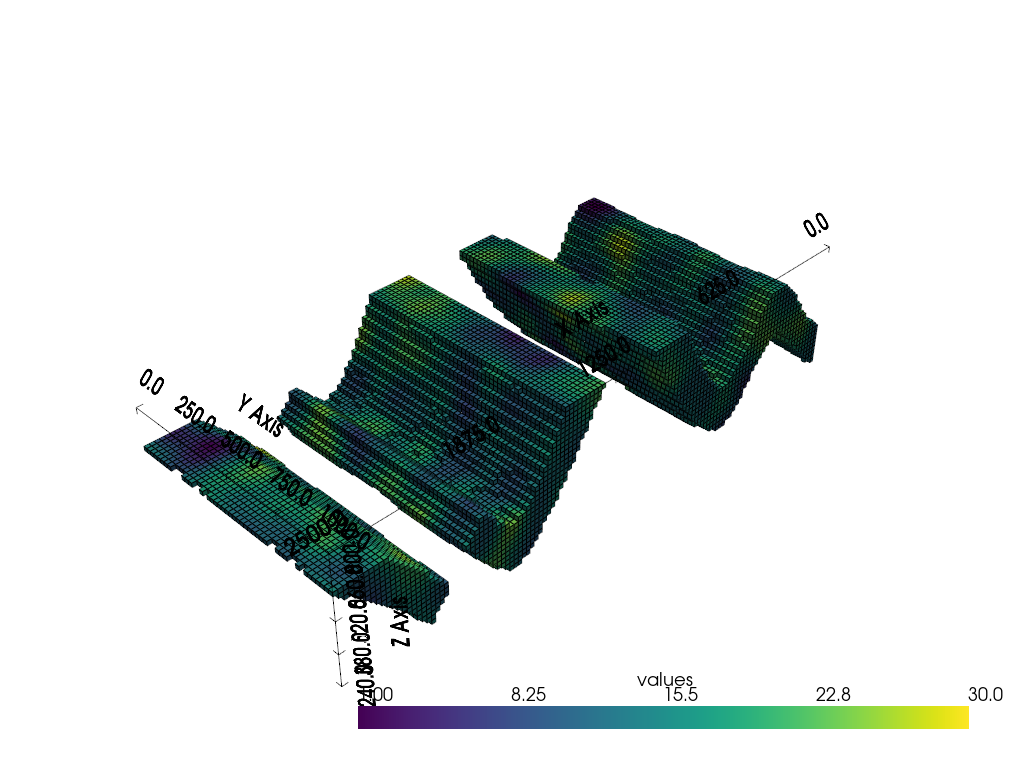

In [10]:
plotter = pv.Plotter()

#for i in range(4):
#    plotter.add_mesh(multi_mesh[i], show_edges=True, style="wireframe", color="gray", opacity=0.5)

plotter.add_mesh(multi_mesh[2], show_edges=True, scalars="values")

# plotter.add_mesh(centers, color="r", point_size=8.0, render_points_as_spheres=True)
# plotter.add_mesh(pvnc[0][2], show_edges=True, style='wireframe')

plotter.show_bounds()
plotter.show()